# TELECOM PARTE 1

# 📌 Extracción

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ayelen95/Chagenge-Telecom-2026/blob/main/TelecomX_LATAM.ipynb)

## Librerias

In [1]:
import pandas as pd 

In [2]:
!pip install requests

In [2]:
# Forma común de acceder a las API es a través de la biblioteca requests
import requests
import json

## Cargamos datos 

### Desde la Api, teniendo link de github

In [ ]:
link = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

In [4]:
datos = requests.get(link).json()
requests.get(link)  # 200 indica que la solicitud fue exitosa


<Response [200]>

Información con DataFrame, solo para observar.

In [5]:
df = pd.DataFrame(datos)
df.head(2)

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


### Desde archivos, subidos en Colab

In [6]:
ruta = '/content/TelecomX_Data.json'

In [ ]:

df = pd.read_json(ruta)
df.head(2)

# 🔧 Transformación

## Conociendo el conjunto de datos

Diccionario de datos

    customerID: número de identificación único de cada cliente
    Churn: si el cliente dejó o no la empresa
    customer.gender: género (masculino y femenino)
    customer.SeniorCitizen: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
    customer.Partner: si el cliente tiene o no una pareja
    customer.Dependents: si el cliente tiene o no dependientes
    customer.tenure: meses de contrato del cliente
    phone.PhoneService: suscripción al servicio telefónico
    phone.MultipleLines: suscripción a más de una línea telefónica
    internet.InternetService: suscripción a un proveedor de internet
    internet.OnlineSecurity: suscripción adicional de seguridad en línea
    internet.OnlineBackup: suscripción adicional de respaldo en línea
    internet.DeviceProtection: suscripción adicional de protección del dispositivo
    internet.TechSupport: suscripción adicional de soporte técnico, menor tiempo de espera
    internet.StreamingTV: suscripción de televisión por cable
    internet.StreamingMovies: suscripción de streaming de películas
    account.Contract: tipo de contrato
    account.PaperlessBilling: si el cliente prefiere recibir la factura en línea
    account.PaymentMethod: forma de pago
    account.Charges.Monthly: total de todos los servicios del cliente por mes
    account.Charges.Total: total gastado por el cliente

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


### Comprobación de incoherencias en los datos

Se observa columnas que contiene listas de diccionario de datos, pasamos variable "datos"

In [9]:
df = pd.json_normalize(datos)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [11]:
print(df.columns.tolist())

['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total']


#### Verificación de valores únicos

In [12]:
df['Churn'].unique()

array(['No', 'Yes', ''], dtype=object)

In [13]:
df['customer.tenure'].unique()

array([ 9,  4, 13,  3, 71, 63,  7, 65, 54, 72,  5, 56, 34,  1, 45, 50, 23,
       55, 26, 69, 11, 37, 49, 66, 67, 20, 43, 59, 12, 27,  2, 25, 29, 14,
       35, 64, 39, 40,  6, 30, 70, 57, 58, 16, 32, 33, 10, 21, 61, 15, 44,
       22, 24, 19, 47, 62, 46, 52,  8, 60, 48, 28, 41, 53, 68, 51, 31, 36,
       17, 18, 38, 42,  0])

In [14]:
df['phone.MultipleLines'].unique()

array(['No', 'Yes', 'No phone service'], dtype=object)

In [15]:
df['internet.TechSupport'].unique()

array(['Yes', 'No', 'No internet service'], dtype=object)

In [16]:
df['account.PaymentMethod'].unique()

array(['Mailed check', 'Electronic check', 'Credit card (automatic)',
       'Bank transfer (automatic)'], dtype=object)

Verificación de valores duplicados

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
print('Duplicados: ',df.duplicated().sum())

Duplicados:  0


Verificacion de valores nulos

In [19]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


Verificación de valores vacios o en blancos

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [21]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


In [22]:
df['Churn'].isnull().sum()

np.int64(0)

In [23]:
for column in df.columns:
    # 1. Detectar NaN (Nulos reales)
    nulos = df[column].isnull().sum()
    # 2. Contar vacíos 
    vacios = 0
    if df[column].dtype == 'object':
        # Usamos strip() para contar también celdas con solo espacios ' ' como vacías
        vacios = (df[column].astype(str).str.strip() == '').sum()
        
    if nulos > 0 or vacios > 0:
        print(f'{column}: {nulos} NaNs, {vacios} strings vacíos/blancos')

Churn: 0 NaNs, 224 strings vacíos/blancos
account.Charges.Total: 0 NaNs, 11 strings vacíos/blancos


In [24]:
df['account.Charges.Total'][0:10]

,account.Charges.Total
0,593.3
1,542.4
2,280.85
3,1237.85
4,267.4
5,571.45
6,7904.25
7,5377.8
8,340.35
9,5957.9


La columna 'account.Charges.Total' de tipo object lo pasamos a float:

In [25]:
# 1. Convertir a NaN
# 'errors=coerce' convierte los strings vacíos que no se pueden transformar en NaN
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

In [26]:
# 2. Eliminar las filas que ahora son NaN (las 11 filas)
df.dropna(subset=['account.Charges.Total'], inplace=True)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7256 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7256 non-null   object 
 1   Churn                      7256 non-null   object 
 2   customer.gender            7256 non-null   object 
 3   customer.SeniorCitizen     7256 non-null   int64  
 4   customer.Partner           7256 non-null   object 
 5   customer.Dependents        7256 non-null   object 
 6   customer.tenure            7256 non-null   int64  
 7   phone.PhoneService         7256 non-null   object 
 8   phone.MultipleLines        7256 non-null   object 
 9   internet.InternetService   7256 non-null   object 
 10  internet.OnlineSecurity    7256 non-null   object 
 11  internet.OnlineBackup      7256 non-null   object 
 12  internet.DeviceProtection  7256 non-null   object 
 13  internet.TechSupport       7256 non-null   object 
 1

Eliminación de strings vacios/blancos de la columna Churn

In [28]:
df = df[df['Churn'] != '']
df = df[df['Churn'] != ' ']

In [29]:
df.reset_index(drop=True, inplace=True)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7032 non-null   object 
 1   Churn                      7032 non-null   object 
 2   customer.gender            7032 non-null   object 
 3   customer.SeniorCitizen     7032 non-null   int64  
 4   customer.Partner           7032 non-null   object 
 5   customer.Dependents        7032 non-null   object 
 6   customer.tenure            7032 non-null   int64  
 7   phone.PhoneService         7032 non-null   object 
 8   phone.MultipleLines        7032 non-null   object 
 9   internet.InternetService   7032 non-null   object 
 10  internet.OnlineSecurity    7032 non-null   object 
 11  internet.OnlineBackup      7032 non-null   object 
 12  internet.DeviceProtection  7032 non-null   object 
 13  internet.TechSupport       7032 non-null   objec

In [31]:
# Verificamos nuevamente nulos y vacíos
for column in df.columns:
    # 1. Detectar NaN (Nulos reales)
    nulos = df[column].isnull().sum()
    # 2. Contar vacíos 
    vacios = 0
    if df[column].dtype == 'object':
        # Usamos strip() para contar también celdas con solo espacios ' ' como vacías
        vacios = (df[column].astype(str).str.strip() == '').sum()
        
    if nulos > 0 or vacios > 0:
        print(f'{column}: {nulos} NaNs, {vacios} strings vacíos/blancos')

### Crear columna "Cuentas_Diarias"

In [32]:
df['Cuentas_Diarias'] = df['account.Charges.Monthly'] / 30

In [33]:
# Redondear a 2 decimales
df['Cuentas_Diarias'] = df['Cuentas_Diarias'].round(2)

In [34]:
print(df[['account.Charges.Monthly', 'Cuentas_Diarias']].tail())

      account.Charges.Monthly  Cuentas_Diarias
7027                    55.15             1.84
7028                    85.10             2.84
7029                    50.30             1.68
7030                    67.85             2.26
7031                    59.00             1.97


### Renombrar nombres de las columnas

In [35]:
df.columns


Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total', 'Cuentas_Diarias'],
      dtype='object')

In [36]:
# Cambiar el nombre de la columnas 

nombres_espanol = {
    'customerID': 'ID_Cliente',
    'Churn': 'Abandono' ,
    'customer.gender': 'Genero',
    'customer.SeniorCitizen': 'Cliente_Mayor_65',
    'customer.Partner': 'En_Pareja',
    'customer.Dependents': 'tiene_Dependientes',
    'customer.tenure': 'Meses_contrato',
    'phone.PhoneService': 'Servicio_Telefonico',
    'phone.MultipleLines': 'Multiples_Lineas',
    'internet.InternetService': 'Servicio_Internet',
    'internet.OnlineSecurity': 'Seguridad_Online',
    'internet.OnlineBackup': 'Backup_Online',
    'internet.DeviceProtection': 'Proteccion_Dispositivo',
    'internet.TechSupport': 'Soporte_Tecnico',
    'internet.StreamingTV': 'TV_Streaming',
    'internet.StreamingMovies': 'Peliculas_Streaming',
    'account.Contract': 'Contrato',
    'account.PaperlessBilling': 'Facturacion_Digital',
    'account.PaymentMethod': 'Metodo_Pago',
    'account.Charges.Monthly': 'Cargos_Mensuales',
    'account.Charges.Total': 'Cargos_Totales',
    
}


df = df.rename(columns=nombres_espanol)

print(df.columns)


Index(['ID_Cliente', 'Abandono', 'Genero', 'Cliente_Mayor_65', 'En_Pareja',
       'tiene_Dependientes', 'Meses_contrato', 'Servicio_Telefonico',
       'Multiples_Lineas', 'Servicio_Internet', 'Seguridad_Online',
       'Backup_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico',
       'TV_Streaming', 'Peliculas_Streaming', 'Contrato',
       'Facturacion_Digital', 'Metodo_Pago', 'Cargos_Mensuales',
       'Cargos_Totales', 'Cuentas_Diarias'],
      dtype='object')


### Estandarización y transformación de datos

In [37]:
df.head(2)

,ID_Cliente,Abandono,Genero,Cliente_Mayor_65,En_Pareja,tiene_Dependientes,Meses_contrato,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,TV_Streaming,Peliculas_Streaming,Contrato,Facturacion_Digital,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,2.00


In [38]:
df_temporal = df.copy()

In [39]:
for col in df_temporal.select_dtypes(include='object').columns:
    if df_temporal[col].unique().size == 2:
        print(f'Columna: {col} - Valores únicos: {df_temporal[col].unique()}')
        df_temporal[col] = df_temporal[col].replace({'Yes': 1, 'No': 0}).infer_objects(copy=False)

Columna: Abandono - Valores únicos: ['No' 'Yes']
Columna: Genero - Valores únicos: ['Female' 'Male']
Columna: En_Pareja - Valores únicos: ['Yes' 'No']
Columna: tiene_Dependientes - Valores únicos: ['Yes' 'No']
Columna: Servicio_Telefonico - Valores únicos: ['Yes' 'No']
Columna: Facturacion_Digital - Valores únicos: ['Yes' 'No']


/tmp/ipython-input-477/1479307062.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temporal[col] = df_temporal[col].replace({'Yes': 1, 'No': 0}).infer_objects(copy=False)


In [40]:
df_temporal.head(2)

,ID_Cliente,Abandono,Genero,Cliente_Mayor_65,En_Pareja,tiene_Dependientes,Meses_contrato,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,TV_Streaming,Peliculas_Streaming,Contrato,Facturacion_Digital,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.3,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.4,2.00


### Renombrar valores de las columnas

In [41]:
df.tail(2)

,ID_Cliente,Abandono,Genero,Cliente_Mayor_65,En_Pareja,tiene_Dependientes,Meses_contrato,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,TV_Streaming,Peliculas_Streaming,Contrato,Facturacion_Digital,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
7030,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.26
7031,9995-HOTOH,No,Male,0,Yes,Yes,63,No,No phone service,DSL,...,Yes,No,Yes,Yes,Two year,No,Electronic check,59.00,3707.60,1.97


In [42]:
for col in df.select_dtypes(include='object').columns:
    if df[col].unique().size == 2:
        print(f'Columna: {col} - Valores únicos: {df[col].unique()}')
        df[col] = df[col].replace({'Yes': 'Si', 'No': 'No'}).infer_objects(copy=False)

Columna: Abandono - Valores únicos: ['No' 'Yes']
Columna: Genero - Valores únicos: ['Female' 'Male']
Columna: En_Pareja - Valores únicos: ['Yes' 'No']
Columna: tiene_Dependientes - Valores únicos: ['Yes' 'No']
Columna: Servicio_Telefonico - Valores únicos: ['Yes' 'No']
Columna: Facturacion_Digital - Valores únicos: ['Yes' 'No']


In [43]:
df['Genero'] = df['Genero'].replace({'Female': 'Femenino','Male': 'Masculino'})

In [44]:
df['Contrato'] = df['Contrato'] .replace({'Month-to-month': 'Mes a mes', 'One year': 'Un año', 'Two year': 'Dos años'})

In [45]:
df['Metodo_Pago'] = df['Metodo_Pago'].replace({'Electronic check': 'Cheque electronico',
                                   'Mailed check': 'Cheque enviado por correo',
                                   'Bank transfer (automatic)': 'Transferencia bancaria (automatica)',
                                   'Credit card (automatic)': 'Tarjeta de credito (automatica)'
                                   })

In [46]:
df['Multiples_Lineas'] = df['Multiples_Lineas'].replace({'No phone service': 'Sin servicio telefonico',
                                               'Yes': 'Si',
                                               'No': 'No'})     

In [47]:
df['Proteccion_Dispositivo'] = df['Proteccion_Dispositivo'].replace({'No internet service': 'Sin servicio de internet',
                                               'Yes': 'Si',
                                               'No': 'No'}) 

In [48]:
df['Soporte_Tecnico'] = df['Soporte_Tecnico'].replace({'No internet service': 'Sin servicio de internet',
                                               'Yes': 'Si', 
                                               'No': 'No'})

In [49]:
df['TV_Streaming'] = df['TV_Streaming'].replace({'No internet service': 'Sin servicio de internet',
                                               'Yes': 'Si', 
                                               'No': 'No'})

In [50]:
df['Peliculas_Streaming'] = df['Peliculas_Streaming'].replace({'No internet service': 'Sin servicio de internet',
                                               'Yes': 'Si',     
                                               'No': 'No'})

In [51]:
df['Servicio_Internet'] = df['Servicio_Internet'].replace({'No': 'No',
                                               'DSL': 'DSL',
                                               'Fiber optic': 'Fibra optica'})  

# 📊 Carga y análisis

## Análisis Descriptivo

In [52]:
df.describe()

,Cliente_Mayor_65,Meses_contrato,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,2.159891
std,0.368844,24.545260,30.085974,2266.771362,1.002955
min,0.000000,1.000000,18.250000,18.800000,0.610000
25%,0.000000,9.000000,35.587500,401.450000,1.187500
50%,0.000000,29.000000,70.350000,1397.475000,2.340000
75%,0.000000,55.000000,89.862500,3794.737500,2.992500
max,1.000000,72.000000,118.750000,8684.800000,3.960000


## Distribución de evasión

In [53]:
import matplotlib.pyplot as plt
import numpy as np

In [54]:
df.head(2)

,ID_Cliente,Abandono,Genero,Cliente_Mayor_65,En_Pareja,tiene_Dependientes,Meses_contrato,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,TV_Streaming,Peliculas_Streaming,Contrato,Facturacion_Digital,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,0002-ORFBO,No,Femenino,0,Si,Si,9,Si,No,DSL,...,No,Si,Si,No,Un año,Si,Cheque enviado por correo,65.6,593.3,2.19
1,0003-MKNFE,No,Masculino,0,No,No,9,Si,Si,DSL,...,No,No,No,Si,Mes a mes,No,Cheque enviado por correo,59.9,542.4,2.00


In [55]:
df['Abandono'].value_counts()

,count
Abandono,
No,5163
Si,1869


In [56]:

conteo = df['Abandono'].value_counts()
conteo

,count
Abandono,
No,5163
Si,1869


In [57]:
# --- 1. Preparación de los datos ---
conteo = df['Abandono'].value_counts()

# Definimos etiquetas y valores para los gráficos
etiquetas = ['Se quedaron (0)', 'Se fueron (1)']
valores = [conteo.iloc[0], conteo.iloc[1]]
colores = ['#2ca02c', '#d62728'] 

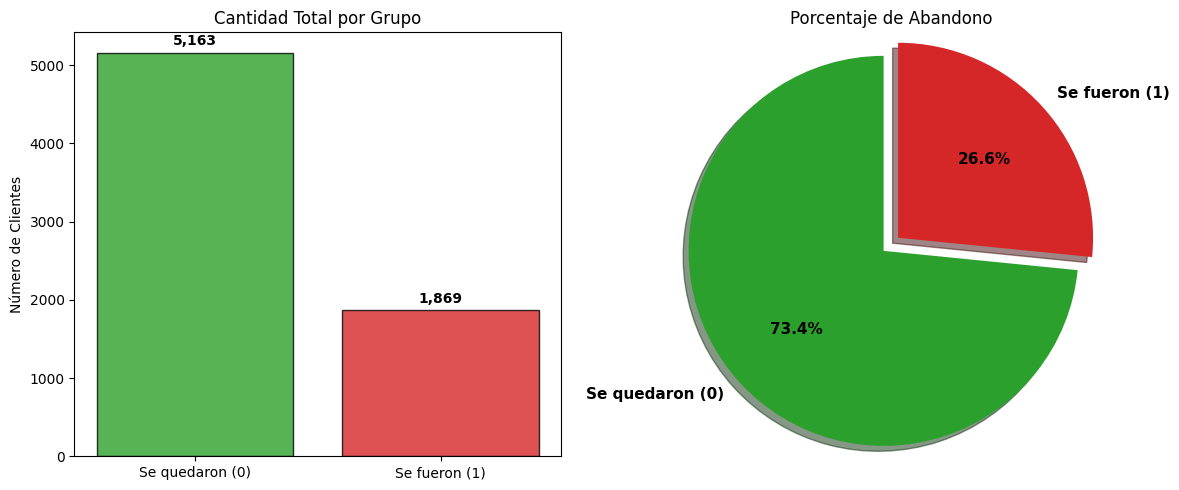

In [58]:
# Crear Estructura
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
# Crear Grafico de Barras
bar_container = axs[0].bar(etiquetas, valores, color=colores, edgecolor='black', alpha=0.8)
axs[0].bar_label(bar_container, fmt='{:,.0f}', padding=3, fontsize=10, fontweight='bold')
axs[0].set_title('Cantidad Total por Grupo', fontsize=12)
axs[0].set_ylabel('Número de Clientes')

# Crear Grafico de Torta
explode = (0, 0.1) # Separar la rebanada de los que se fueron
axs[1].pie(valores, labels=etiquetas, autopct='%1.1f%%'
           , startangle=90, colors=colores, 
           shadow= True,                   
           explode=explode,
           textprops={'fontsize': 11, 'fontweight': 'bold', 'color': 'black'} # Texto dentro de la torta
           )

axs[1].set_title('Porcentaje de Abandono', fontsize=12)
axs[1].axis('equal')  # Asegura que la torta sea un círculo perfecto

plt.tight_layout() # Evita que los títulos se superpongan
plt.show()


## Recuento de evasión por variables categóricas

Ahora, exploraremos cómo se distribuye la evasión según variables categóricas, como género, tipo de contrato, método de pago, entre otras.

 Variables categóricas: Abandono, Genero, En_Pareja, tiene_Dependientes, Servicio_Telefonico, Multiples_Lineas, Servicio_Internet, Seguridad_Online, Backup_Online, Proteccion_Dispositivo, Soporte_Tecnico, TV_Streaming, Peliculas_Streaming, Contrato, Facturacion_Digital, Metodo_Pago

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_Cliente              7032 non-null   object 
 1   Abandono                7032 non-null   object 
 2   Genero                  7032 non-null   object 
 3   Cliente_Mayor_65        7032 non-null   int64  
 4   En_Pareja               7032 non-null   object 
 5   tiene_Dependientes      7032 non-null   object 
 6   Meses_contrato          7032 non-null   int64  
 7   Servicio_Telefonico     7032 non-null   object 
 8   Multiples_Lineas        7032 non-null   object 
 9   Servicio_Internet       7032 non-null   object 
 10  Seguridad_Online        7032 non-null   object 
 11  Backup_Online           7032 non-null   object 
 12  Proteccion_Dispositivo  7032 non-null   object 
 13  Soporte_Tecnico         7032 non-null   object 
 14  TV_Streaming            7032 non-null   

In [61]:
import seaborn as sns

In [62]:
sns.set_theme(style='whitegrid')

In [ ]:
# funcion para graficar barras con seaborn y matplotlib
def plot_bar(dataframe, variable_x=None, variable_y=None, hue_var=None, \
             colores='pastel', title=None, xlabel=None, ylabel=None, rotacion=0, tamanio=(10,8)):     

    fig, ax = plt.subplots(figsize=tamanio)

    sns.countplot(
        data=dataframe, 
        x=variable_x, 
        y=variable_y, 
        hue=hue_var,
        palette=colores, 
        alpha=.8,
        #estimator=sum, 
        edgecolor='black', 
        ax=ax 
    )

    ax.set_title(title, fontsize=16)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Rotación del eje X
    if variable_x: 
        plt.xticks(rotation=rotacion, ha='right')

    
    for container in ax.containers:
        ax.bar_label(container, fmt='{:,.0f}', padding=3, fontweight='bold')

    plt.tight_layout()

    plt.show()

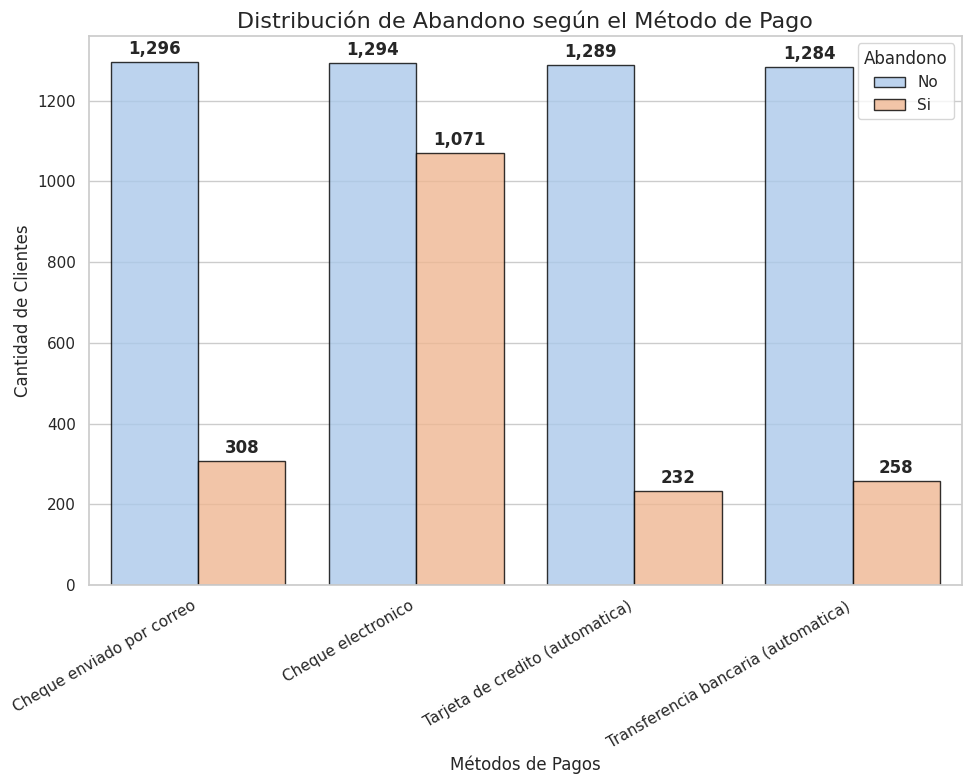

In [65]:
plot_bar (
    dataframe=df,
    variable_x='Metodo_Pago',
    #variable_y='Abandono',
    hue_var='Abandono',
    title='Distribución de Abandono según el Método de Pago',
    xlabel='Métodos de Pagos',
    ylabel='Cantidad de Clientes',
    rotacion=30
)

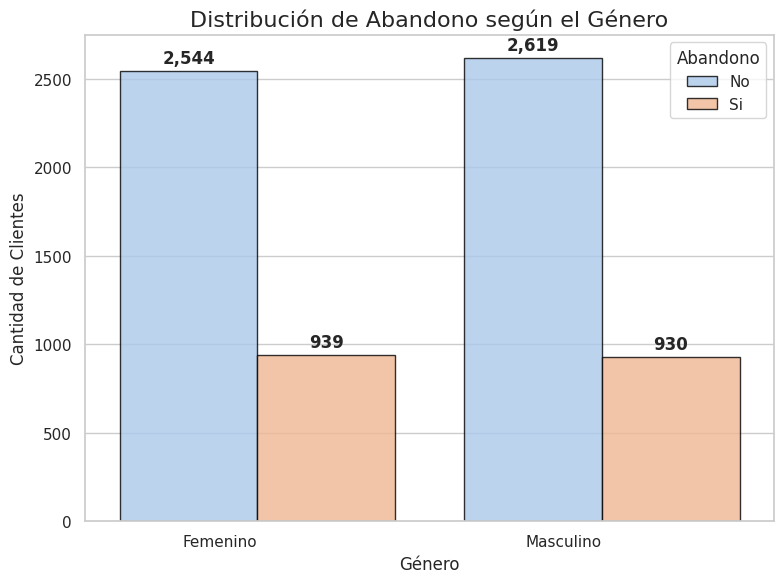

In [66]:
plot_bar (
    dataframe=df,
    variable_x='Genero',
    #variable_y='Abandono',
    hue_var='Abandono',
    title='Distribución de Abandono según el Género',
    xlabel='Género',
    ylabel='Cantidad de Clientes',
    tamanio=(8,6)
)

In [67]:
# Definimos los parámetros personalizados
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="whitegrid", rc=custom_params)

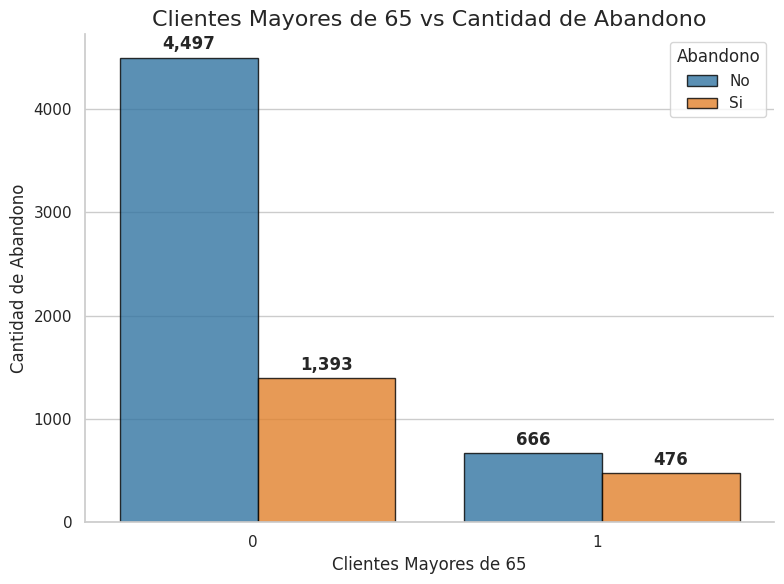

In [ ]:
plot_bar (
    colores='tab10',
    dataframe=df,#dataframe=df[df['Abandono'] == 'Si'],
    variable_x='Cliente_Mayor_65',
    hue_var='Abandono',
    title='Clientes Mayores de 65 vs Cantidad de Abandono',
    xlabel='Clientes Mayores de 65',
    ylabel='Cantidad de Abandono',
    tamanio=(8,6)
)

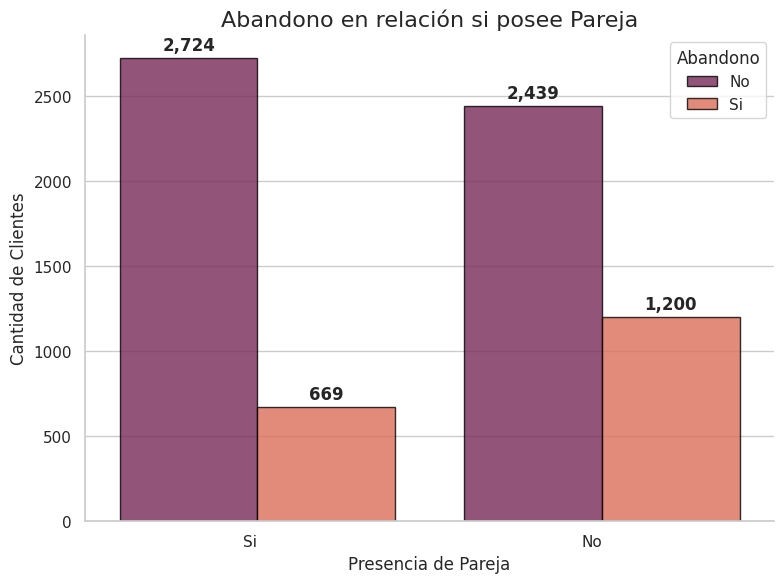

In [ ]:
plot_bar (
    colores='rocket',
    dataframe=df,
    variable_x='En_Pareja',
    hue_var='Abandono',
    title='Abandono en relación si posee Pareja',
    xlabel='Presencia de Pareja',
    ylabel='Cantidad de Clientes',
    tamanio=(8,6)
)

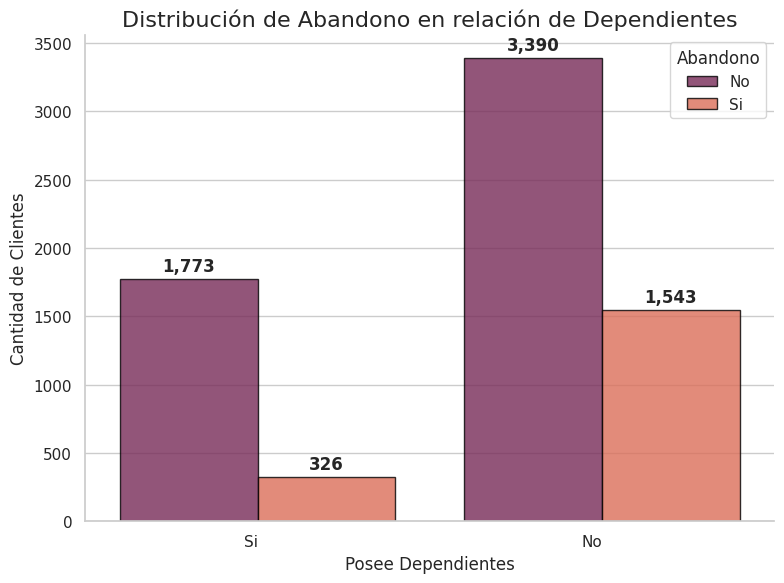

In [70]:
# tiene_Dependientes   :
plot_bar (
    colores='rocket',
    dataframe=df,
    variable_x='tiene_Dependientes',
    hue_var='Abandono',
    title='Distribución de Abandono en relación de Dependientes',
    xlabel='Posee Dependientes',
    ylabel='Cantidad de Clientes',
    tamanio=(8,6)
)

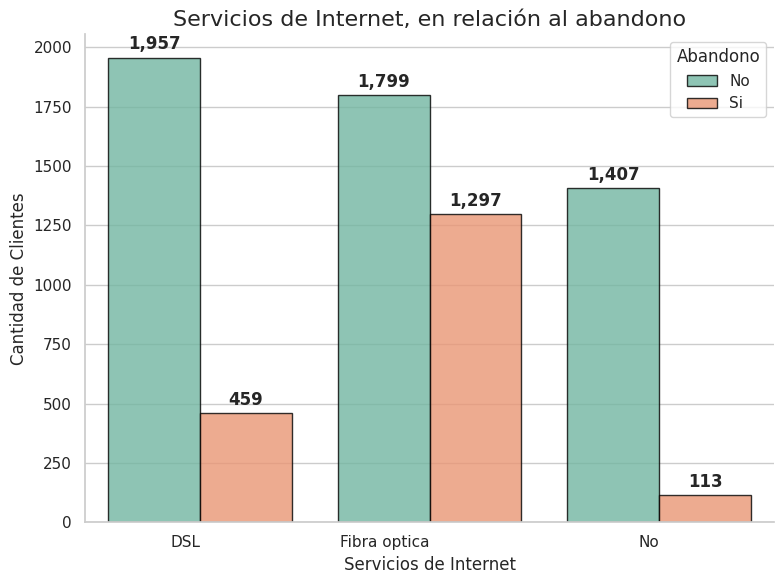

In [71]:
# Servicios de Internet, en relación al abandono    :
plot_bar (
    colores='Set2',
    dataframe=df,
    variable_x='Servicio_Internet',
    hue_var='Abandono',
    title='Servicios de Internet, en relación al abandono',
    xlabel='Servicios de Internet',
    ylabel='Cantidad de Clientes',
    tamanio=(8,6)
)

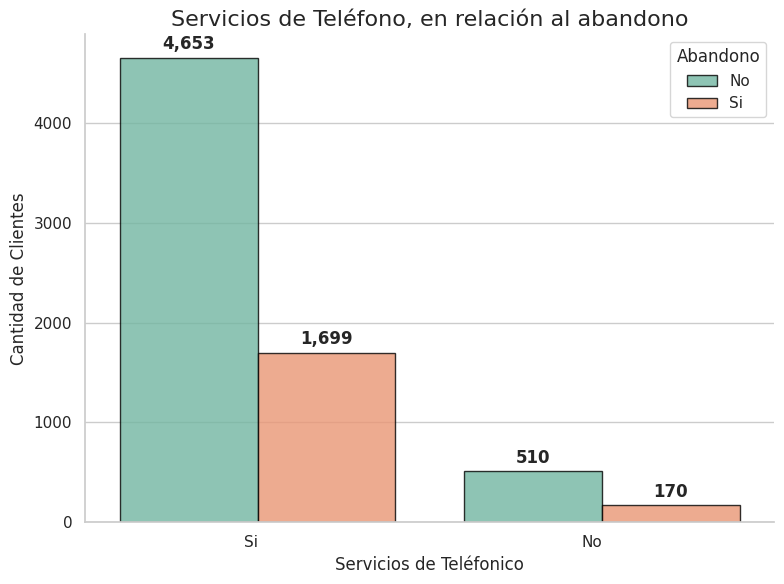

In [ ]:
# Servicios de Telefono, en relación al abandono    :
plot_bar (
    colores='Set2',
    dataframe=df,
    variable_x='Servicio_Telefonico',
    hue_var='Abandono',
    title='Servicios de Teléfono, en relación al abandono',
    xlabel='Servicios de Teléfonico',
    ylabel='Cantidad de Clientes',
    tamanio=(8,6)
)

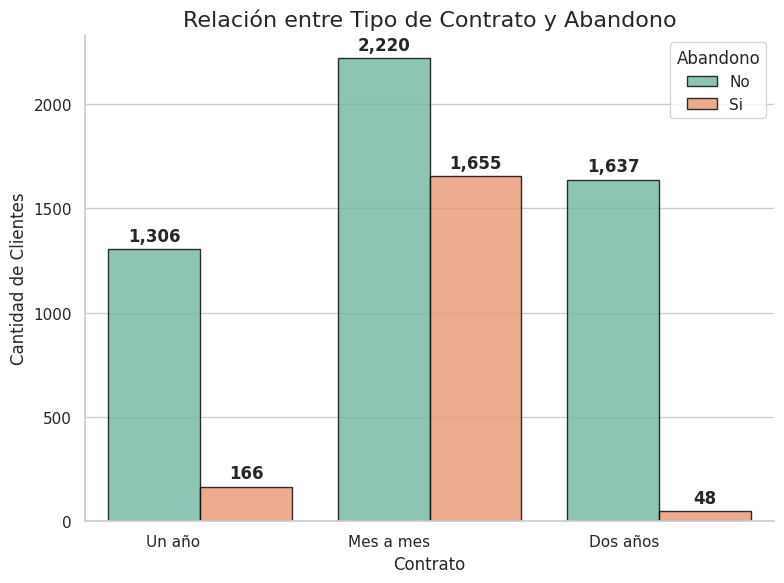

In [74]:
# Relación entre Tipo de Contrato y Abandono   :
plot_bar (
    colores='Set2',
    dataframe=df,
    variable_x='Contrato',
    hue_var='Abandono',
    title='Relación entre Tipo de Contrato y Abandono',
    xlabel='Contrato',
    ylabel='Cantidad de Clientes',
    tamanio=(8,6)
)

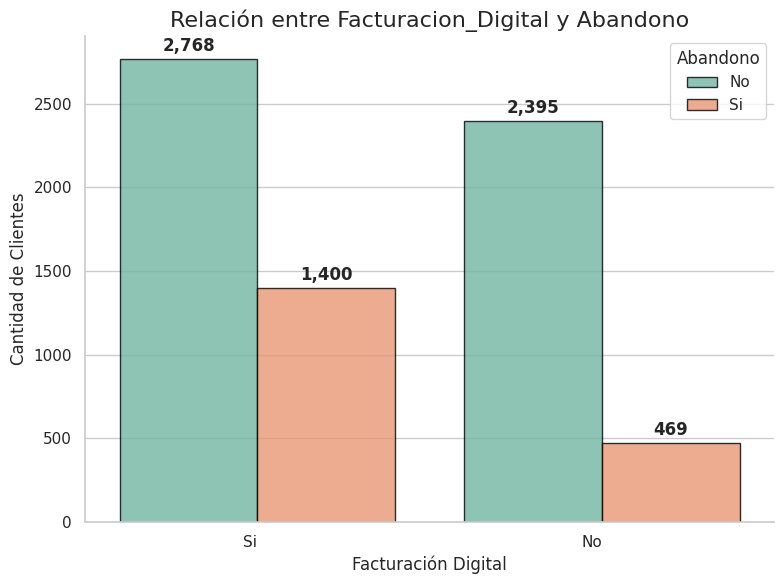

In [75]:
plot_bar (
    colores='Set2',
    dataframe=df,
    variable_x='Facturacion_Digital',
    hue_var='Abandono',
    title='Relación entre Facturacion_Digital y Abandono',
    xlabel='Facturación Digital',
    ylabel='Cantidad de Clientes',
    tamanio=(8,6)
)

In [76]:
import plotly.express as px

In [77]:
# Se le indica a Plotly que estás trabajando en un entorno de VS Code (Mime Type). 
import plotly.io as pio
pio.renderers.default = "notebook_connected"

In [78]:
fig = px.sunburst(
    df,
    path=['Abandono', 'Metodo_Pago','Servicio_Internet'],
    color='Metodo_Pago',
    title='Distribución de Clientes por Servicio de Internet, Pago y Abandono',
    width=750, height=750
)
# Actualizamos las etiquetas para que muestre el nombre y el porcentaje
fig.update_traces(textinfo="label+percent entry")
fig.show()

In [79]:
fig = px.sunburst(
    df,
    path=['En_Pareja', 'Metodo_Pago', 'Abandono'], 
    color='Abandono',
    title='Distribución de Clientes en Pareja, Pago y Abandono',
    width=750, height=750
)
# Actualizamos las etiquetas para que muestre el nombre y el porcentaje
fig.update_traces(textinfo="label+percent entry")
fig.show()

In [80]:
fig = px.sunburst(
    df,
    path=['Abandono', 'Cliente_Mayor_65', 'TV_Streaming'], 
    color='Abandono',
    title='Distribución de Clientes Mayores, TV_Streaming y Abandono',
    width=750, height=750
)
# Actualizamos las etiquetas para que muestre el nombre y el porcentaje
fig.update_traces(textinfo="label+percent entry")
fig.show()

In [81]:
fig = px.sunburst(
    df,
    path=['Abandono', 'Cliente_Mayor_65', 'Servicio_Telefonico'], 
    color='Abandono',
    title='Distribución de Abandon con respecto a Clientes Mayores y Servicio Teléfonico',
    width=750, height=750
)
# Actualizamos las etiquetas para que muestre el nombre y el porcentaje
fig.update_traces(textinfo="label+percent entry")
fig.show()

In [ ]:

fig = px.histogram(df, 
                   x="Metodo_Pago", 
                   color="Abandono", 
                   barmode="group", 
                   title="Abandono por Método de Pago",
                   text_auto=True 
                   )

fig.show()

In [ ]:

# Usamos histograma
fig = px.histogram(df, 
                   x="Abandono", 
                   color="tiene_Dependientes", 
                   barmode="group", 
                   title="Abandono por Presencia de Dependientes",
                   text_auto=True 
                   )

fig.show()

## Conteo de evasión por variables numéricas

En este paso, explora cómo las variables numéricas, como "total gastado" o "tiempo de contrato", se distribuyen entre los clientes que cancelaron (evasión) y los que no cancelaron.
Variables Numéricas: Cargos_Mensuales, Cargos_Totales y Cuentas_Diarias

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_Cliente              7032 non-null   object 
 1   Abandono                7032 non-null   object 
 2   Genero                  7032 non-null   object 
 3   Cliente_Mayor_65        7032 non-null   int64  
 4   En_Pareja               7032 non-null   object 
 5   tiene_Dependientes      7032 non-null   object 
 6   Meses_contrato          7032 non-null   int64  
 7   Servicio_Telefonico     7032 non-null   object 
 8   Multiples_Lineas        7032 non-null   object 
 9   Servicio_Internet       7032 non-null   object 
 10  Seguridad_Online        7032 non-null   object 
 11  Backup_Online           7032 non-null   object 
 12  Proteccion_Dispositivo  7032 non-null   object 
 13  Soporte_Tecnico         7032 non-null   object 
 14  TV_Streaming            7032 non-null   

<Figure size 800x600 with 0 Axes>

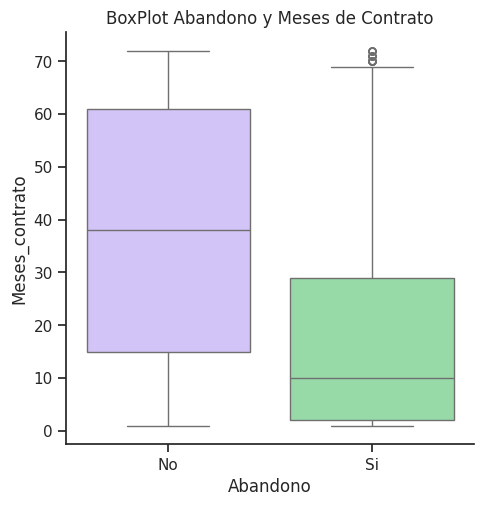

In [100]:
sns.set_theme(style="ticks", palette="pastel")
plt.figure(figsize=(8, 6))
sns.catplot(data=df, x="Abandono", y="Meses_contrato", kind="box",palette=["m", "g"], hue='Abandono', legend=False)
plt.title('BoxPlot Abandono y Meses de Contrato')
plt.show()

In [101]:
fig = px.box(df, x="Abandono", y="Meses_contrato", color='Abandono', title='BoxPlot Abandono y Meses de Contrato')
fig.show()

In [102]:


fig = px.box(df, x="Abandono", y="Meses_contrato", color="Metodo_Pago", title='Gráfico de Abandono en relación con Meses de Contrato y Método de Pago')
fig.show()

In [104]:
px.histogram(df, x = 'Cargos_Totales', text_auto = True, color = 'Abandono', barmode = 'group', title='Abandono en Relación a Cargos Totales')

In [105]:
px.histogram(df, x = 'Cargos_Mensuales', text_auto = True, color = 'Abandono', barmode = 'group', title='Abandono en relación con Cargos Mensuales')

In [106]:
px.histogram(df, x = 'Meses_contrato', text_auto = True, color = 'Abandono', barmode = 'group', title='Abandono en relación a Meses de contrato')

# EXTRA - Análisis de correlación entre variables

Paso adicional, puedes explorar la correlación entre diferentes variables del dataset. 

Esto puede ayudar a identificar qué factores tienen mayor relación con la evasión de clientes, como:

    🔹 La relación entre la cuenta diaria y la evasión.
    🔹 Cómo la cantidad de servicios contratados afecta la probabilidad de churn.


In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

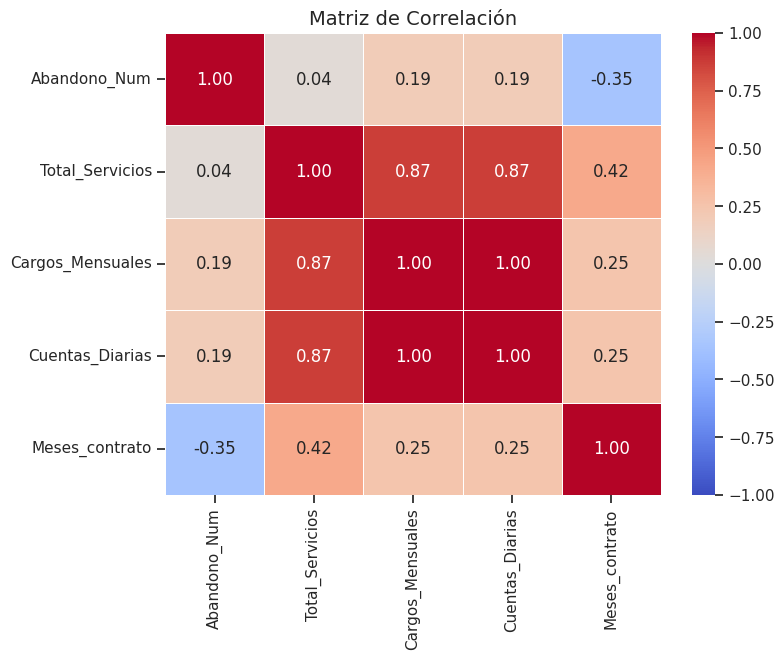

In [ ]:
df_extra = df.copy() # Creamos copia del df original, para hacer uso de corr() se necesita variables númericas

# Convertir el Abandono ("Sí"/"No") a 1 y 0 
df_extra['Abandono_Num'] = df_extra['Abandono'].map({'Si': 1, 'No': 0})

# Crear 'Total_Servicios' 
cols_servicios = ['Servicio_Telefonico', 'Multiples_Lineas', 'Servicio_Internet', 
                  'Seguridad_Online', 'Backup_Online', 'Proteccion_Dispositivo', 
                  'Soporte_Tecnico', 'TV_Streaming', 'Peliculas_Streaming']

# Contamos cuántos servicios tiene cada cliente
df_extra['Total_Servicios'] = df_extra[cols_servicios].apply(lambda x: x.isin(['Si', 'DSL', 'Fibra optica']).sum(), axis=1)


columnas_a_comparar = ['Abandono_Num', 'Total_Servicios', 'Cargos_Mensuales','Cuentas_Diarias', 'Meses_contrato']

# Calculo de la matriz de correlación
matriz_correlacion = df_extra[columnas_a_comparar].corr()

# Grafico de Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacion, 
            annot=True,       # Muestra los números
            fmt=".2f",        # 2 decimales
            cmap="coolwarm",  # Paleta de colores de frío a calor
            vmin=-1, vmax=1,  # La correlación siempre va de -1 a 1
            linewidths=0.5)

plt.title('Matriz de Correlación', fontsize=14)
plt.show()

# 📄 Informe final


## 📊 Análisis de deserción de Clientes en Telecom

### 🔍 Introducción

En la industria de las telecomunicaciones, la retención de clientes es un factor crítico para la rentabilidad. El fenómeno conocido como Churn (Evasión o Abandono) representa la tasa a la cual los clientes dejan de utilizar los servicios de la empresa.

Objetivo del Análisis: El propósito de este proyecto es explorar un conjunto de datos históricos de clientes para identificar patrones de comportamiento que influyen en la decisión de abandonar el servicio. 

---

### 🧹 Limpieza y Tratamiento de Datos
Antes del análisis, se realizaron los siguientes pasos de pre-procesamiento:
* Eliminación de valores duplicados, nulos y vaciós.
* Conversión de la columna `TotalCharges` a numérica, también se realizó manejo de cadenas vacías columna `Churn`.
* Se convirtieron nombres de columnas y valores a español para tener un entendimiento mejor.
* Mapeo de variables categóricas (0/1 a "No/Sí") para mejorar la legibilidad de los gráficos(Heatmap).

---

### 🔍 Análisis Exploratorio de Datos

#### 1. La Influencia del Tipo de Contrato
El análisis revela que la flexibilidad contractual es el factor #1 de riesgo.

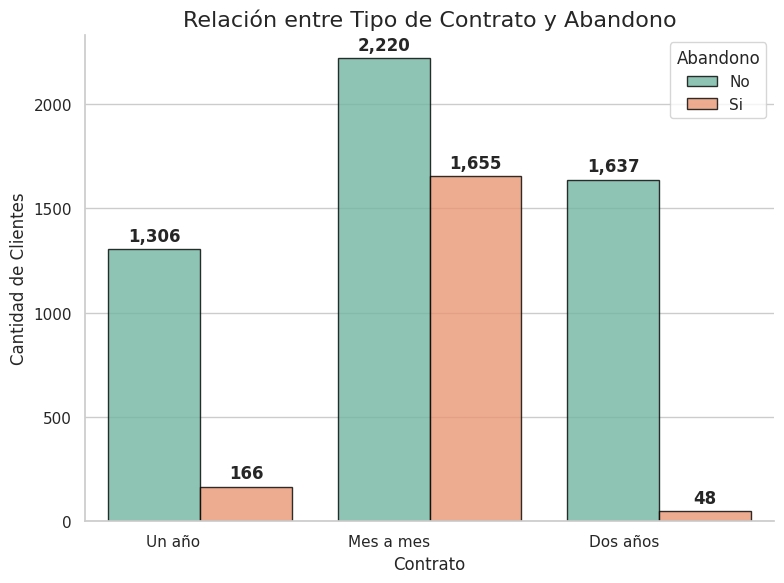

* **Insight:** Los clientes con contrato **"Mes a Mes"** representan la gran mayoría de los abandonos. Los contratos a largo plazo (1 o 2 años) generan una lealtad casi total.

#### 2. Anomalía en los Métodos de Pago
Al analizar cómo pagan los clientes, descubrimos un comportamiento inusual que requiere atención inmediata.

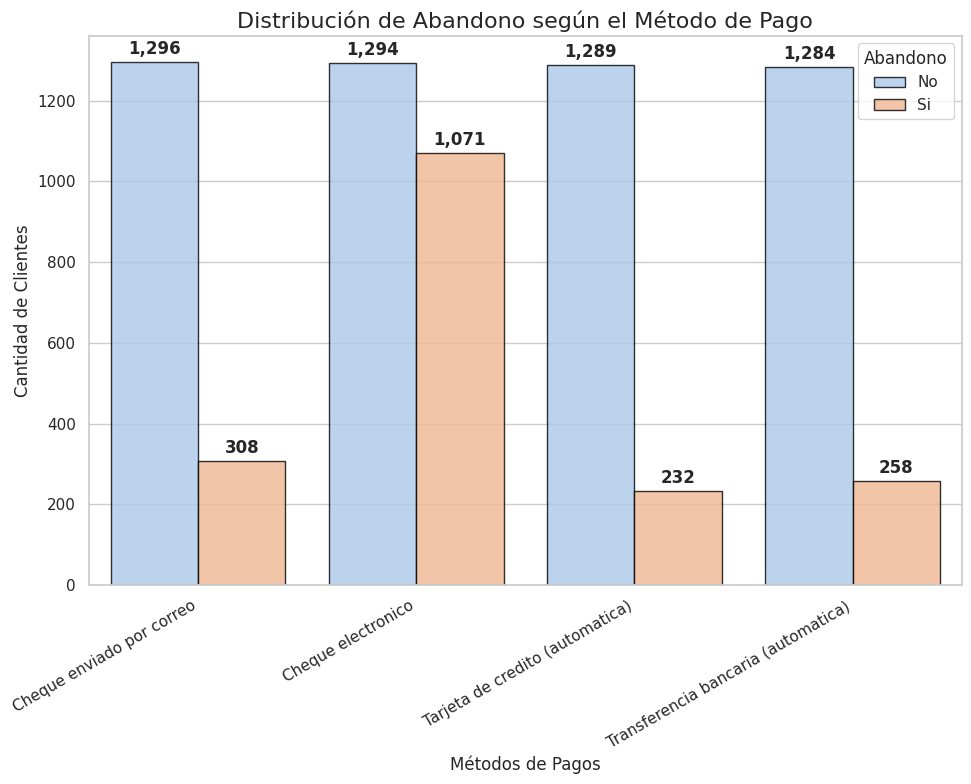

* **Insight:** Los clientes con el método **"Cheque Electronico"** de pago representan la gran mayoría de los abandonos.

#### 3. La "Zona de Peligro" (Antigüedad)
Utilizando Boxplots, analizamos la distribución de la permanencia de los clientes.

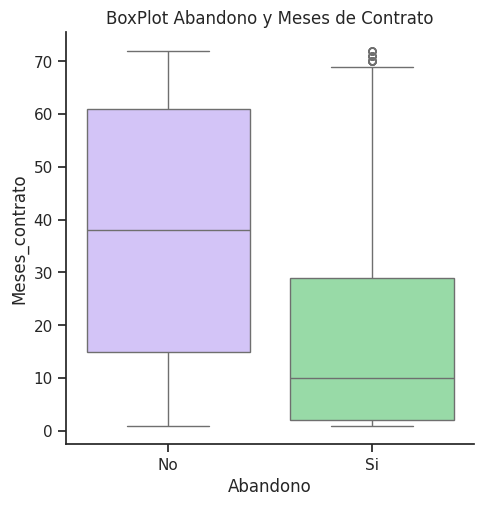

<p align="center">
  <img src="images/barrasMeses.png" width="600" alt="Gráfico de meses de contratos">
</p>


* **Insight:** La mediana de antigüedad de los clientes que se van es de apenas **10 meses**. Si un cliente supera los primeros 2 años, la probabilidad de abandono cae drásticamente.

---

### 🚀 Conclusiones e Insights

A partir de la evidencia visual y estadística recolectada:

1.  La falta de compromiso facilita la fuga: El contrato "Mes a Mes" es el principal motor de abandono. Los clientes sin ataduras a largo plazo son altamente volátiles. Por el contrario, los contratos de 1 a 2 años aseguran una retención casi total.

2. El "Cheque Electrónico": Este método de pago concentra una tasa de abandono desproporcionadamente alta en comparación con otros métodos de pago.

3. El riesgo se concentra en el primer año: El análisis de antigüedad demuestra que la mediana de fuga se ubica en los primeros 10 meses. Si un cliente supera la barrera de los 2 años, la probabilidad de perderlo cae drásticamente.

---

### 🔮 Recomendaciones

1.  **Migración de Contratos:** Diseñar campañas para mover a clientes "Mes a Mes" hacia contratos anuales.
2.  **Primer Año - Bienvenida:** Implementar un programa de fidelización durante los primeros 12 meses, involucrando al Soporte Técnico y Atención al Cliente.
3.  **Revisión de Métodos de Pago:** Investigar fallos o experiencias en el pago con "Cheque Electrónico".
4.  **Promoción de Venta Cruzada:** Si el cliente adquiere un servicio, ofrecer otros servicios de prueba(6 meses) o descuento especial. Más servicios más permanencia en la empresa.


